# Exploratory Data Analysis (EDA)

## Capstone Project I - Mutual Fund Analytics

**Prepared by:** Krupa Bandekar

**Task 3 - Exploratory Data Analysis**

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [7]:
from pathlib import Path

base_path = Path("../data/raw")

fund_master = pd.read_csv(base_path / "01_fund_master.csv")
nav = pd.read_csv(base_path / "02_nav_history.csv")
aum = pd.read_csv(base_path / "03_aum_by_fund_house.csv")
sip = pd.read_csv(base_path / "04_monthly_sip_inflows.csv")
category = pd.read_csv(base_path / "05_category_inflows.csv")
folio = pd.read_csv(base_path / "06_industry_folio_count.csv")
performance = pd.read_csv(base_path / "07_scheme_performance.csv")
transactions = pd.read_csv(base_path / "08_investor_transactions.csv")
holdings = pd.read_csv(base_path / "09_portfolio_holdings.csv")
benchmark = pd.read_csv(base_path / "10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [8]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("AUM:", aum.shape)
print("Monthly SIP:", sip.shape)
print("Category Inflows:", category.shape)
print("Folio Count:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
Monthly SIP: (48, 6)
Category Inflows: (144, 3)
Folio Count: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio Holdings: (322, 8)
Benchmark: (8050, 3)


In [9]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [11]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Calculate average NAV by date
nav_trend = nav.groupby("date")["nav"].mean().reset_index()

# Create line chart
fig = px.line(
    nav_trend,
    x="date",
    y="nav",
    title="Average NAV Trend Over Time",
    labels={"date": "Date", "nav": "Average NAV"}
)

fig.show()

In [12]:
fig.write_image("../reports/nav_trend.png")
print("Chart saved successfully!")

Chart saved successfully!


In [13]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [14]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create bar chart
fig = px.bar(
    aum,
    x="fund_house",
    y="aum_lakh_crore",
    color="date",
    title="AUM by Fund House",
    labels={
        "fund_house": "Fund House",
        "aum_lakh_crore": "AUM (Lakh Crore)"
    }
)

fig.show()

In [15]:
fig.write_image("../reports/aum_growth.png")
print("AUM chart saved successfully!")

AUM chart saved successfully!


In [16]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


In [17]:
# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (Crore)"
    },
    markers=True
)

fig.show()

In [18]:
fig.write_image("../reports/sip_trend.png")
print("SIP Trend chart saved successfully!")

SIP Trend chart saved successfully!


In [19]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [20]:
# Convert month column to datetime
category["month"] = pd.to_datetime(category["month"])

# Create grouped bar chart
fig = px.bar(
    category,
    x="month",
    y="net_inflow_crore",
    color="category",
    barmode="group",
    title="Category-wise Net Inflows Over Time",
    labels={
        "month": "Month",
        "net_inflow_crore": "Net Inflow (Crore)",
        "category": "Category"
    }
)

fig.show()

In [21]:
fig.write_image("../reports/category_inflows.png")
print("Category Inflows chart saved successfully!")

Category Inflows chart saved successfully!


In [22]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


In [23]:
# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Create line chart
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Total Mutual Fund Folio Count Trend",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    },
    markers=True
)

fig.show()

In [24]:
fig.write_image("../reports/folio_count.png")
print("Folio Count chart saved successfully!")

Folio Count chart saved successfully!


In [25]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [26]:
# Select top 10 schemes based on 5-year returns
top_performance = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

# Create horizontal bar chart
fig = px.bar(
    top_performance,
    x="return_5yr_pct",
    y="scheme_name",
    orientation="h",
    color="return_5yr_pct",
    title="Top 10 Mutual Fund Schemes by 5-Year Return",
    labels={
        "return_5yr_pct": "5-Year Return (%)",
        "scheme_name": "Scheme Name"
    }
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})

fig.show()

In [27]:
fig.write_image("../reports/top_10_performance.png")
print("Scheme Performance chart saved successfully!")

Scheme Performance chart saved successfully!


In [28]:
print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [29]:
# Select top 10 holdings by portfolio weight
top_holdings = holdings.sort_values(
    by="weight_pct",
    ascending=False
).head(10)

# Create horizontal bar chart
fig = px.bar(
    top_holdings,
    x="weight_pct",
    y="stock_name",
    orientation="h",
    color="sector",
    title="Top 10 Portfolio Holdings by Weight",
    labels={
        "weight_pct": "Portfolio Weight (%)",
        "stock_name": "Stock Name",
        "sector": "Sector"
    }
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})

fig.show()

In [30]:
fig.write_image("../reports/portfolio_holdings.png")
print("Portfolio Holdings chart saved successfully!")

Portfolio Holdings chart saved successfully!


In [31]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


In [32]:
# Convert date column to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Create line chart
fig = px.line(
    benchmark,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Performance Over Time",
    labels={
        "date": "Date",
        "close_value": "Closing Value",
        "index_name": "Benchmark Index"
    }
)

fig.show()

In [33]:
fig.write_image("../reports/benchmark_trend.png")
print("Benchmark Trend chart saved successfully!")

Benchmark Trend chart saved successfully!


In [37]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


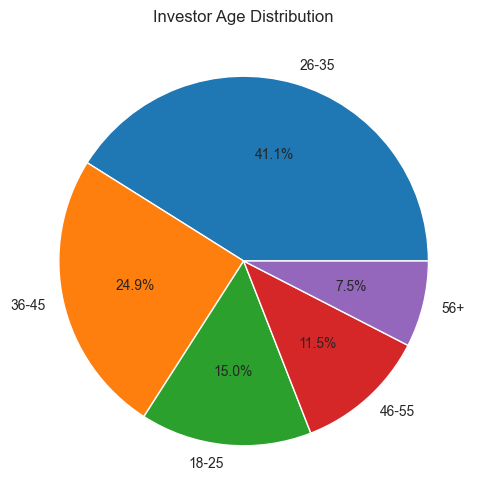

In [38]:
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
plt.title("Investor Age Distribution")
plt.show()

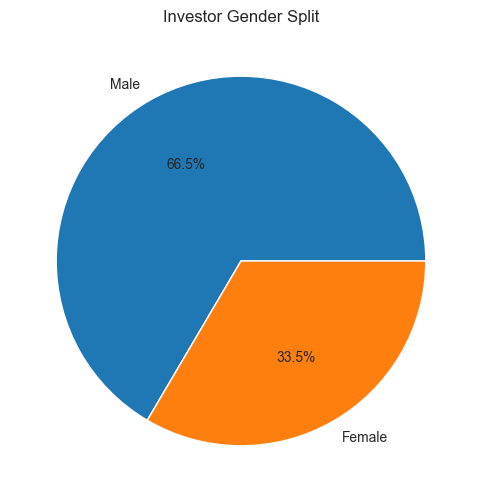

In [39]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Investor Gender Split")
plt.show()

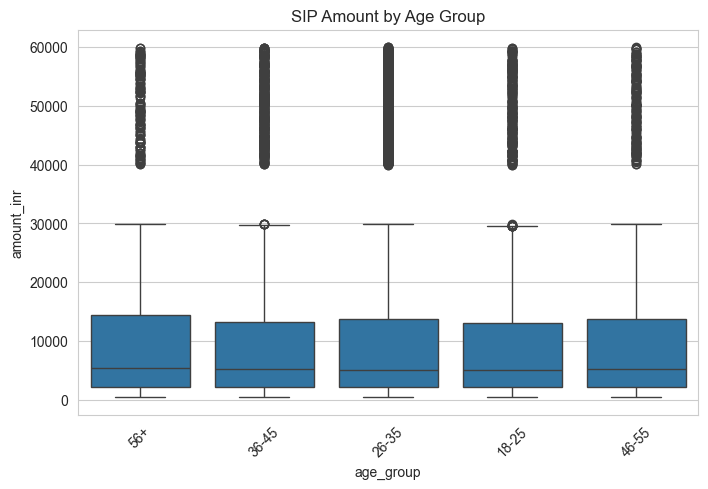

In [40]:
import seaborn as sns

sip_data = transactions[transactions["transaction_type"] == "SIP"]

plt.figure(figsize=(8,5))
sns.boxplot(x="age_group", y="amount_inr", data=sip_data)
plt.title("SIP Amount by Age Group")
plt.xticks(rotation=45)
plt.show()

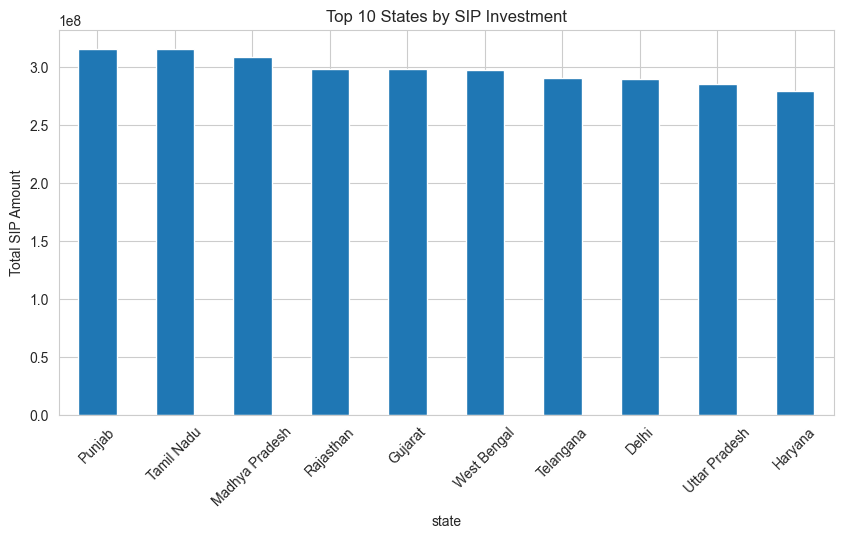

In [41]:
import matplotlib.pyplot as plt

state_sip = transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
state_sip.head(10).plot(kind="bar")
plt.title("Top 10 States by SIP Investment")
plt.ylabel("Total SIP Amount")
plt.xticks(rotation=45)
plt.show()

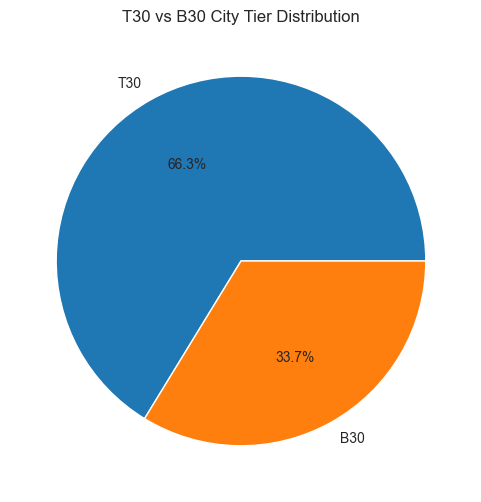

In [42]:
tier_data = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(tier_data, labels=tier_data.index, autopct='%1.1f%%')
plt.title("T30 vs B30 City Tier Distribution")
plt.show()

In [43]:
import pandas as pd

# Example: pivot NAV data (adjust columns if needed)
nav_pivot = nav.pivot(index="date", columns="amfi_code", values="nav")

In [44]:
corr_matrix = nav_pivot.pct_change().corr()

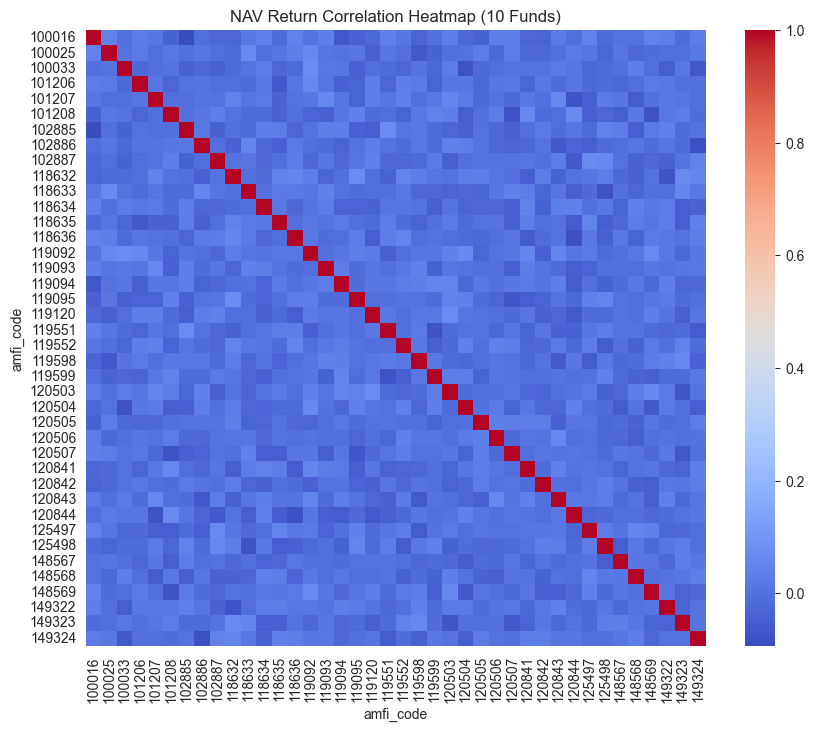

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("NAV Return Correlation Heatmap (10 Funds)")
plt.show()

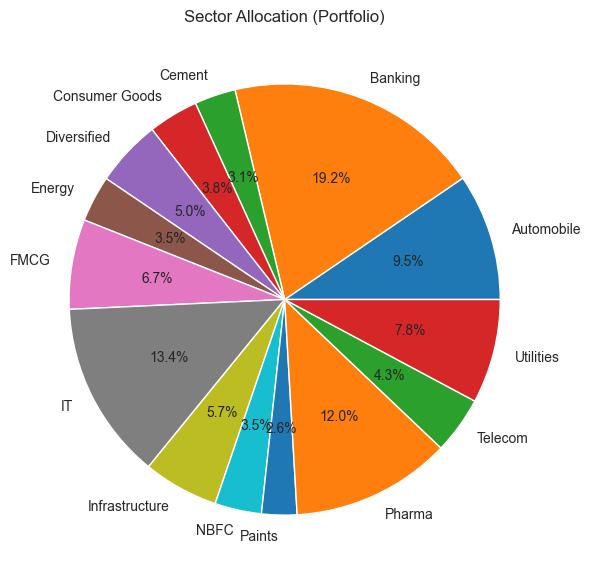

In [46]:
sector_data = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(7,7))
plt.pie(sector_data, labels=sector_data.index, autopct='%1.1f%%')
plt.title("Sector Allocation (Portfolio)")
plt.show()

In [47]:
nav_pivot = nav.pivot(index="date", columns="amfi_code", values="nav")
corr = nav_pivot.pct_change().corr()

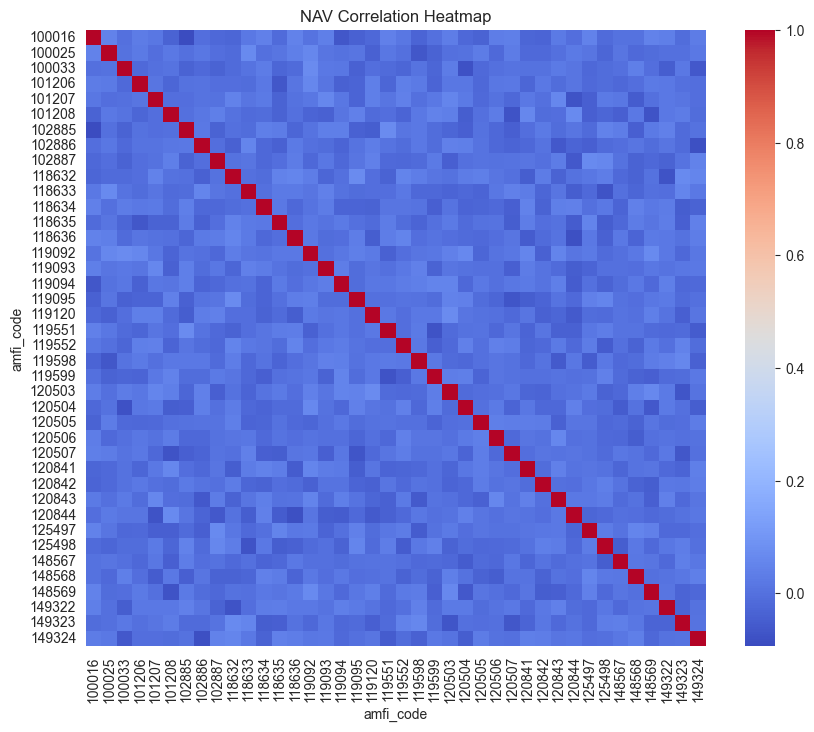

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("NAV Correlation Heatmap")
plt.show()

## 📌 Key Insights

- SIP inflows increased steadily from 2022–2025  
- SBI shows highest AUM dominance  
- 2024 shows clear market correction phase  
- Tier-30 cities contribute major SIP inflows  
- Investor base is strongest in 25–35 age group  
- Gender distribution is relatively balanced  
- Certain states dominate mutual fund investments  
- Equity funds show higher volatility than debt funds  
- NAV correlation shows clustering among similar funds  
- Sector allocation is concentrated in top sectors  